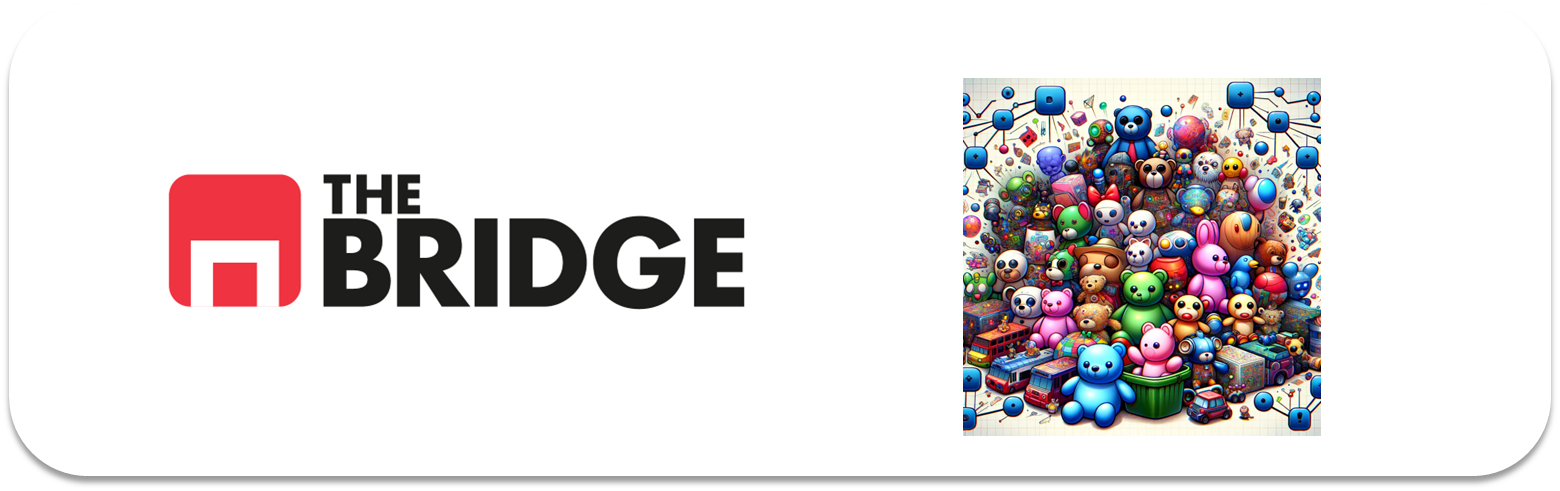

## PRACTICA OBLIGATORIA: **DBSCAN y Clustering Jerárquico**

* La práctica obligatoria de esta unidad consiste en un ejercicio de modelado no supervisado aplicado a clustering jerárquico y no jerárquico. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [87]:
# Common imports
import numpy as np
import pandas as pd
import seaborn as sns

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib.pyplot as plt

# Ignore useless warnings (see SciPy issue #5998)
import warnings
warnings.filterwarnings(action="ignore", message="^internal gelsd")

from sklearn.preprocessing import StandardScaler # escalado de mis features

from sklearn.cluster import DBSCAN # modelo 1
from sklearn.cluster import KMeans # modelo 2
from sklearn.metrics import silhouette_score

### Parte I. Modelado

#### Descripción del problema.

En una planta de experimentación con nuevas bebidas energéticas están trabajando con diferentes mezclas de componentes para obtener posibles variedades de su producto estrella "NonstopU". El problema es que la fabricación de cada "prototipo" conlleva demasiado tiempo y las pruebas de sabores y de propiedades "non-stop" antisueño y antifatiga son costosas.  

En ese sentido quieren construir algún sistema de segmentación previa de mezclas sin probarlas solo indicando las cantidades de cada componente de la bebida. Tienen datos pero desgraciadamente de mezclas anteriores con diferentes medidas pero que por temas presupuestarios y de prioridad no se hicieron test con usuarios y potenciales clientes, es decir no tienen un target de capacidad antifatiga o de preferncia del usuario que puedas servirles para construir un clasificador clásico como han hecho otras veces.  

Han acudido a vosotros con la necesida de encontrar ese segmentador de posibles bebidas y con los datos de las mezclas no probadas anteriores por ver si vostros podéis ayudarles a encontrar algún tipo de segmentación que luego ello se encargarían de interpretar. No es requisito obligatorio pero les gustaría también poder establecer algún tipo de relación entre las segmentaciones (tipo cuales segmentos se "parecerían" más entre sí)

NOTA ORIENTATIVA: Los químicos no esperan que haya menos de 3 segmentos ni más de 5.  
NOTA OPERATIVA: El dataset con los datos que nos han dado los químicos está en "./data/empowering_drinks.csv"

**Se pide**: Construir al menos dos algoritmos de clustering (DBSCAN debe ser uno de ellos y el otro debería estar claro cual deberíamos usar dado el enunciado). Compararlos brevemente aunque sea meramente especulativo (¿Por qué es espculativo?)

**Se recomienda**: Visualizar las features dos a dos para escoger las mejores, no necesariamente hay que usar todas, ni tampoco quedarse en dos. Probar diferentes hiperparámetros en función de la nota orientativa y explicar porqué se han escogido los que finalmente se hayan escogido. 

Recuerda que el proceso es similar a lo que vimos en el otro tipo de aprendizaje:
1. Entender el problema
2. Cargar datos, visualizar.
3. MiniEDA: Selección de features
4. Tratamiento de Features.
5. Selección de modelos, selección de hiperparámetros
6. Entrenamiento, visualización de resultados.
7. Discusión de los mismos


### 1. Entender el problema:

- Tenemos mezclas de bebidas energéticas.
- Cada fila corresponde a una mezcla.
- En las columnas, las cantidades de componentes.
- No hay target, al ser aprendizaje no supervisado de clustering.
- Debemos segmentar posibles tipos de bebidas.

### 2. Carga de datos y visualizaciones:

In [88]:
df = pd.read_csv("./data/empowering_drinks.csv", sep="|")
df.head()

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.518613,0.232053,1.034819,1.013009,0.251717
1,0.246290,-0.827996,0.733629,0.965242,-0.293321
2,0.196879,1.109334,1.215533,1.395148,0.269020
3,1.691550,0.487926,1.466525,2.334574,1.186068
4,0.295700,1.840403,0.663351,-0.037874,-0.319276


In [89]:
# no tenemos nulos, tenemos todas las variables numéricas también.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Azúcares               153 non-null    float64
 1   Vitamínas del grupo B  153 non-null    float64
 2   Cafeína                153 non-null    float64
 3   Ácido Cítrico          153 non-null    float64
 4   Taurina                153 non-null    float64
dtypes: float64(5)
memory usage: 6.1 KB


In [90]:
df.isna().sum()

Azúcares                 0
Vitamínas del grupo B    0
Cafeína                  0
Ácido Cítrico            0
Taurina                  0
dtype: int64

In [91]:
df.describe()

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
count,153.000000,153.000000,153.000000,153.000000,153.000000
mean,0.019231,0.037273,0.041057,0.080022,-0.044088
std,1.026182,0.995984,1.040928,1.009450,0.934399
min,-2.434235,-3.679162,-1.695971,-1.493188,-1.634288
25%,-0.816038,-0.499016,-1.043392,-0.738463,-0.799428
50%,0.061000,-0.023821,0.211566,-0.165254,-0.154899
75%,0.876275,0.707247,0.894264,0.917474,0.493956
max,2.259772,3.156325,3.062832,2.971473,2.431870


### 3. Mini-EDA y selección de features:

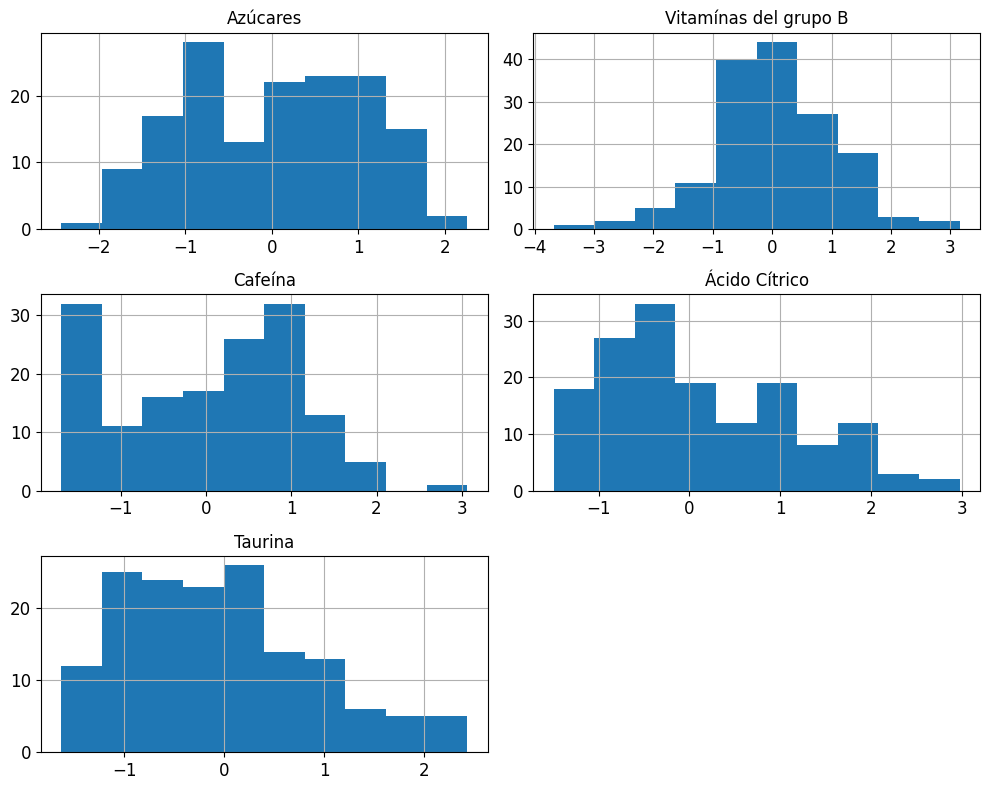

In [92]:
# visualizamos datos:

df.hist(figsize=(10,8))
plt.tight_layout()

Visualizamos datos, vemos que en algunas podemos tener outliers, en azúcares, cafeína y vitamínas, aunque los revisaremos con más detalle más adelante. La distribución no es mala en general, veremos cuáles debemos escalar.
- Hay 253 muestras distintas
- Niveles de azúcares, entre -2.43 y 2.25
- Vitamínas del grupo B, entre -3.67 y 3.15
- Cafeína entre -1.69 y 3.06
- Ácido cítrico entre -1.49 y 2.97
- Taurina entre -1.63 y 2,43

Los valores se concentran entre -3 y 3 aproximadamente, lo cual indica que no parece necesario aplicar un escalado antes de entrenar los modelos, ya que las escalas de las variables se parecen.


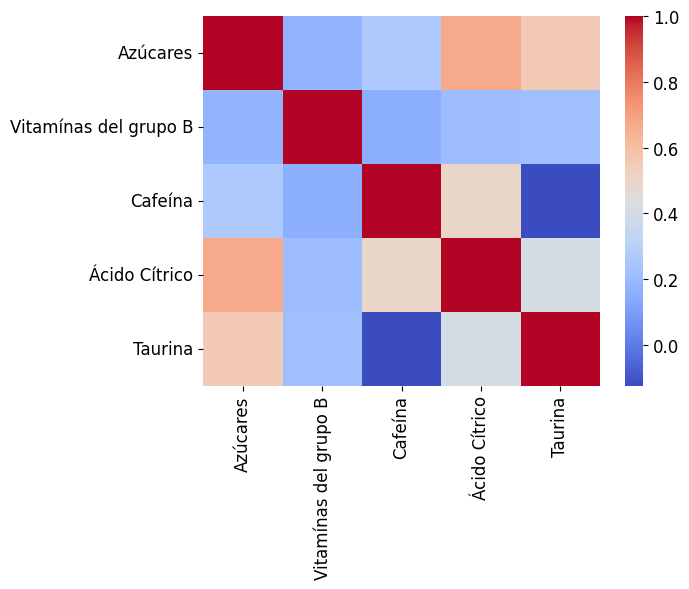

In [93]:
sns.heatmap(df.corr(), cmap="coolwarm");

- Hay una mayor correlación entre:
    - azúcares y ácido cítrico
    - cafeína y ácido cítrico
    - taurina y azucares

Lo veremos con la visualización de features 2 a 2.

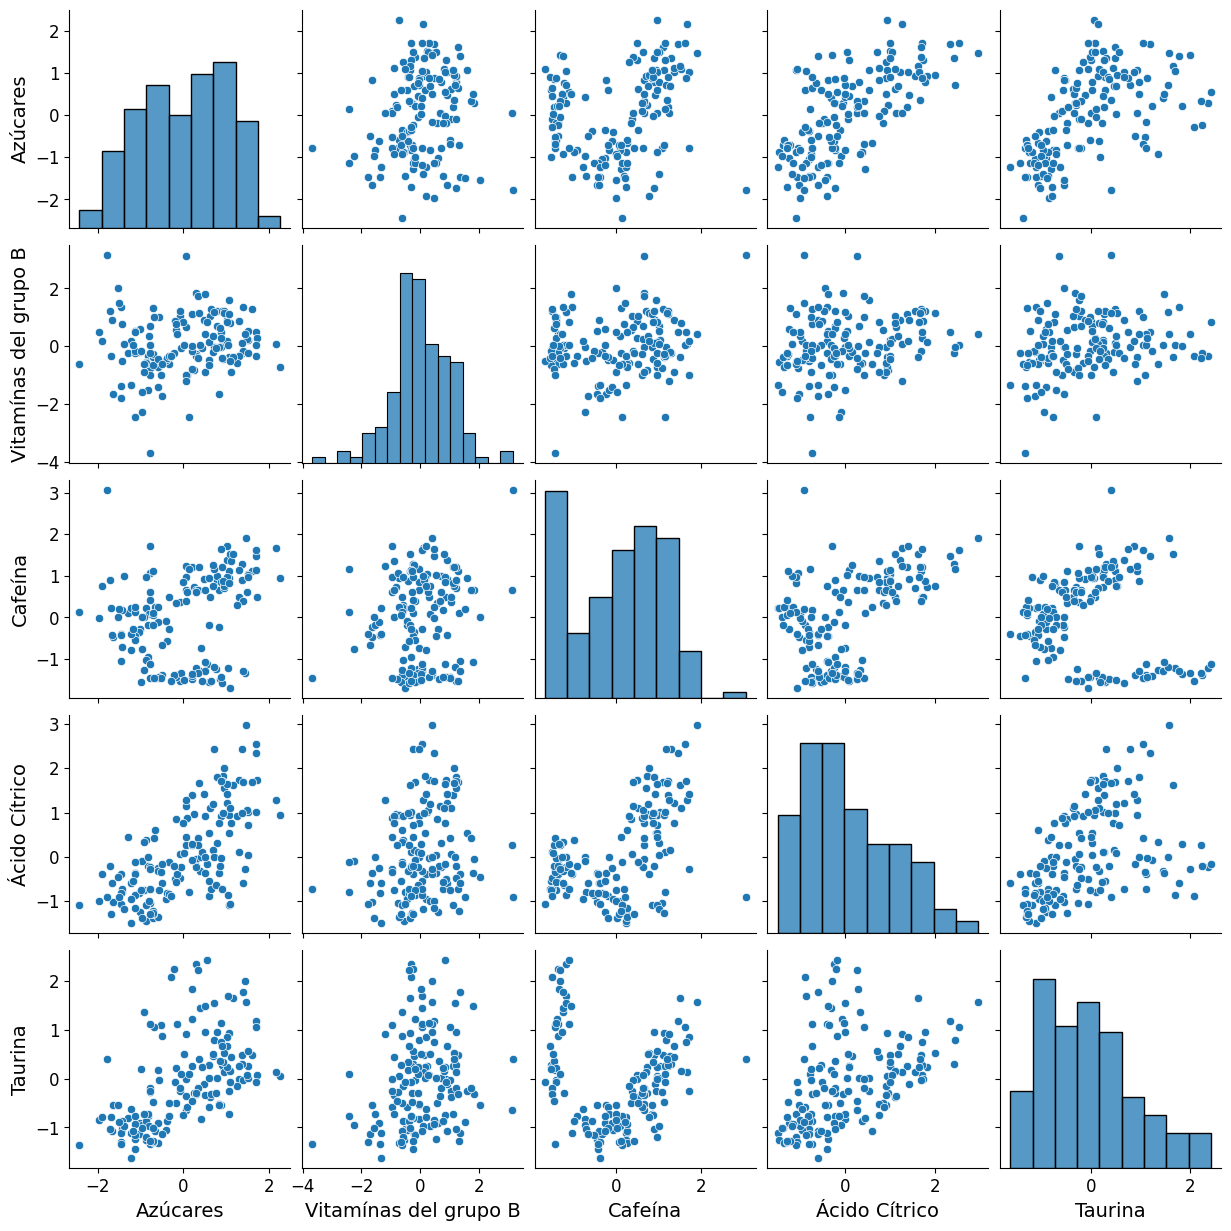

In [94]:
sns.pairplot(df);

En el pairplot no se intuyen grupos diferenciados más allá de las mezclas de:

 - cafeína con la taurina, 
 - azúcares con la cafeína, 
 - cafeína con ácido cítrico,

lo que nos sugiere que la cafeína es el ingrediente más relevante para la bebida energética.
 
Vamos a verlas con más detalle:

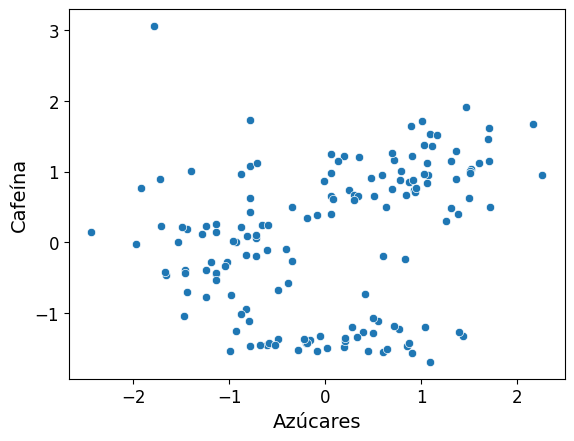

In [95]:
sns.scatterplot(x=df['Azúcares'],
                y=df['Cafeína']);

Parece haber un mayor número de bebidas con más concentración de cafeína y azúcares.

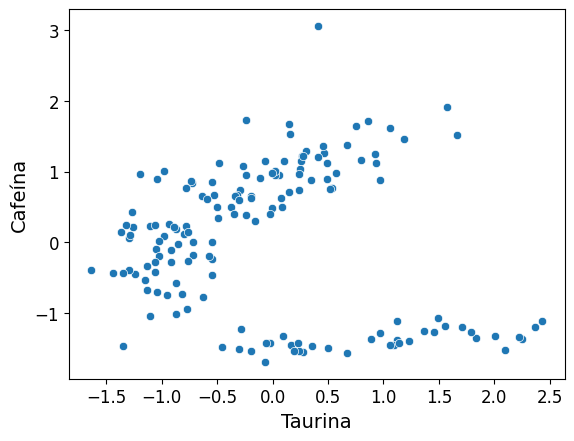

In [96]:
sns.scatterplot(x=df['Taurina'],
                y=df['Cafeína']);

Asimismo, a mayores niveles de cafeína, un descenso del uso de taurina.

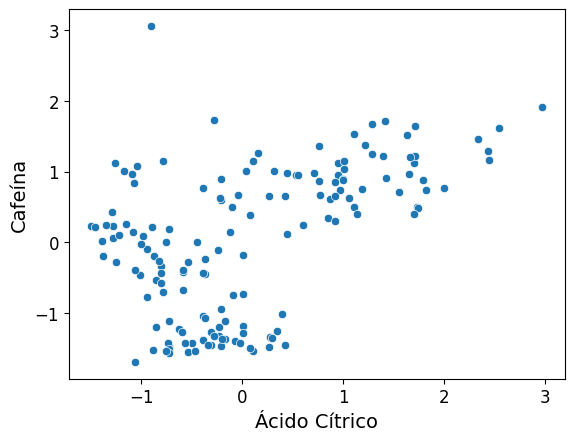

In [97]:
sns.scatterplot(x=df['Ácido Cítrico'],
                y=df['Cafeína']);

Las bebidas con cafeína parecen tener bajas concentraciones de ácido cítrico.

**Conclusión del mini-EDA:**

Tras ver las correlaciones, se seleccionan las features Cafeína, Azúcares, Ácido Cítrico y Taurina, ya que presentan patrones diferenciados en las visualizaciones y pueden estar relacionadas con diferentes tipos de bebida energética.

### 4. Tratamiento de features:

In [98]:
# selecciono mis features:

features_def = ["Cafeína", "Azúcares", "Ácido Cítrico", "Taurina"]
features = df[features_def]

In [99]:
# las escalamos:

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

### 5. Selección de modelos e hiperparámetros:

- Usaremos el modelo DBSCAN con eps 0.2, con min_samples=5.
- Usaremos también K-Means con k=3,4,5 para ver su comportamiento.

### 6. Entrenamiento y visualización de resultados:

**DBSCAN:**

In [100]:
# DBSCAN con eps= 0.4:

dbscan = DBSCAN(eps=0.4, min_samples=4)
dbscan.fit(features_scaled)

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",0.4
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",4
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [101]:
# resultados:
# El algoritmo
print(dbscan)

# Todos los datos etiquetados
print(len(dbscan.labels_))

# Los 10 primeros labels
print(dbscan.labels_[:10])

# Cuantos clusters ha montado
print(np.unique(dbscan.labels_))


DBSCAN(eps=0.4, min_samples=4)
153
[-1  1 -1 -1 -1 -1 -1 -1 -1 -1]
[-1  0  1  2  3  4]


In [102]:
def plot_dbscan(dbscan, X, size, show_xlabels=True, show_ylabels=True):
    core_mask = np.zeros_like(dbscan.labels_, dtype=bool)
    core_mask[dbscan.core_sample_indices_] = True
    anomalies_mask = dbscan.labels_ == -1
    non_core_mask = ~(core_mask | anomalies_mask)

    cores = dbscan.components_
    anomalies = X[anomalies_mask]
    non_cores = X[non_core_mask]
    
    plt.scatter(cores[:, 0], cores[:, 1],
                c=dbscan.labels_[core_mask], marker='o', s=size, cmap="Paired")
    plt.scatter(cores[:, 0], cores[:, 1], marker='*', s=20, c=dbscan.labels_[core_mask])
    plt.scatter(anomalies[:, 0], anomalies[:, 1],
                c="r", marker="x", s=100)
    plt.scatter(non_cores[:, 0], non_cores[:, 1], c=dbscan.labels_[non_core_mask], marker=".")
    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)
    plt.title("eps={:.2f}, min_samples={}".format(dbscan.eps, dbscan.min_samples), fontsize=14)

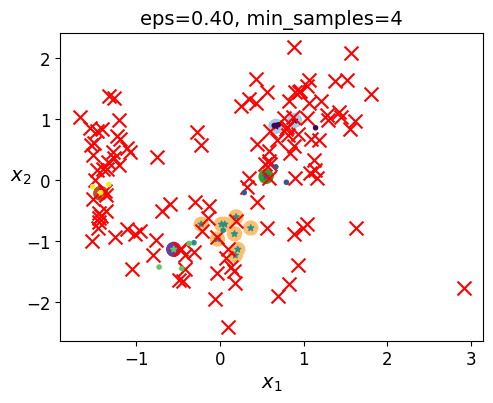

In [103]:
plt.figure(figsize=(12, 4))

plt.subplot(121)
plot_dbscan(dbscan, features_scaled, size=100)

Tras probar distintos valores para **eps** y **min_sample**, encuentro que el modelo detecta muchos outliers y no es óptimo para separar clusters con este dataframe.

**K-Means:**

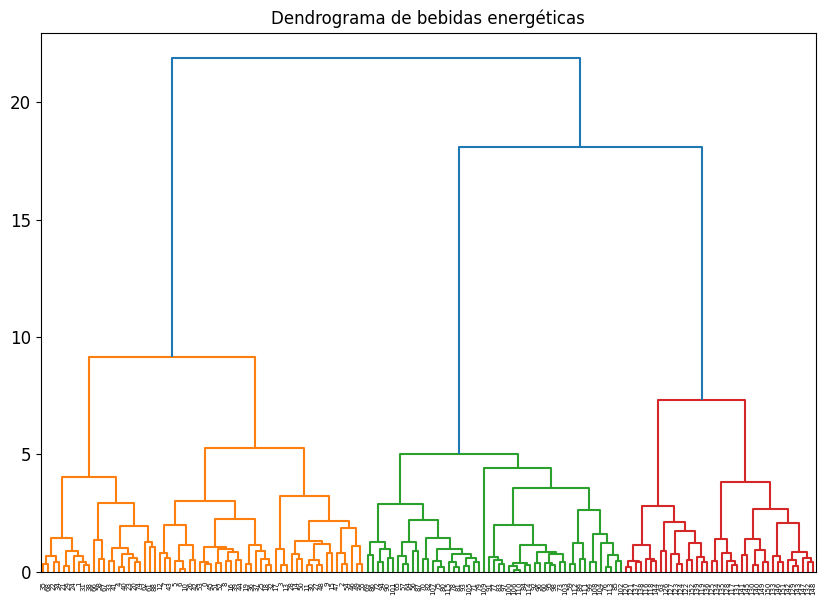

In [104]:
# Hacemos un dendrograma para ver el estimado valor de k:
plt.figure(figsize=(10, 7))
plt.title("Dendrograma de bebidas energéticas")

selected_data = features_scaled
clusters = shc.linkage(selected_data, 
            method='ward', # Este hiperparámetro y el siguiente tienen que ver con la distancia entre clústeres y los veremos un poco más adelante
            metric="euclidean")
shc.dendrogram(Z=clusters)
plt.show();

Parece que el valor óptimo de k es igual a 3. Aun así, probaremos los otros dos.

In [105]:
# primero buscamos el mayor silhouette score con k=3:

kmeans3 = KMeans(n_clusters=3, random_state=42)
labels3 = kmeans3.fit_predict(features_scaled)
score3 = silhouette_score(X_scaled, labels3)
print(f"K=3, Silhouette Score={score3:.3f}")

K=3, Silhouette Score=0.479


In [106]:
# k=4
kmeans4 = KMeans(n_clusters=4, random_state=42)
labels4 = kmeans4.fit_predict(features_scaled)
score4 = silhouette_score(X_scaled, labels4)
print(f"K=4, Silhouette Score={score4:.3f}")

K=4, Silhouette Score=0.398


In [107]:
# k=5
kmeans5 = KMeans(n_clusters=5, random_state=42)
labels5 = kmeans5.fit_predict(features_scaled)
score5 = silhouette_score(X_scaled, labels5)
print(f"K=5, Silhouette Score={score5:.3f}")

K=5, Silhouette Score=0.371


El mejor valor de k para este caso es 3. Entrenamos con este valor:

In [108]:
# lo entrenamos y sacamos las etiquetas 
best_k = 3  # según el Silhouette Score más alto
kmeans_final = KMeans(n_clusters=best_k, random_state=42)
labels_final = kmeans_final.fit_predict(features_scaled)

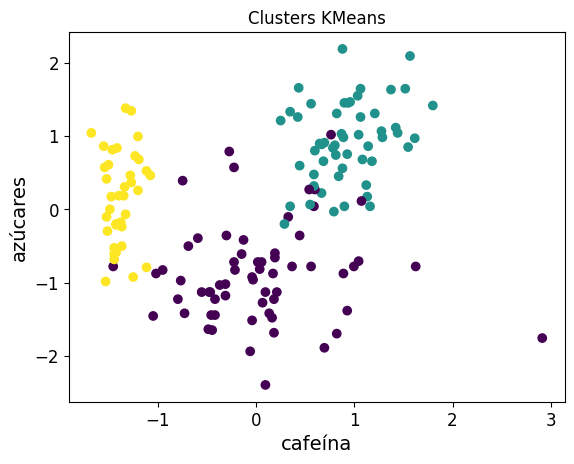

In [109]:
# los visualizamos por pares:
plt.scatter(features_scaled[:,0], features_scaled[:,1], c=labels_final, cmap='viridis')
plt.xlabel("cafeína")
plt.ylabel("azúcares")
plt.title("Clusters KMeans")
plt.show();

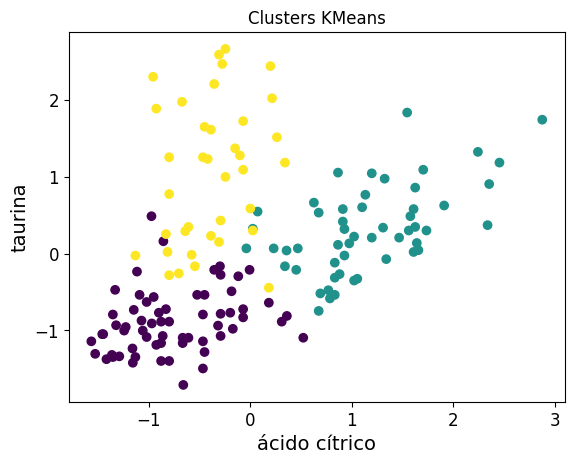

In [110]:
plt.scatter(features_scaled[:,2], features_scaled[:,3], c=labels_final, cmap='viridis')
plt.xlabel("ácido cítrico")
plt.ylabel("taurina")
plt.title("Clusters KMeans")
plt.show();

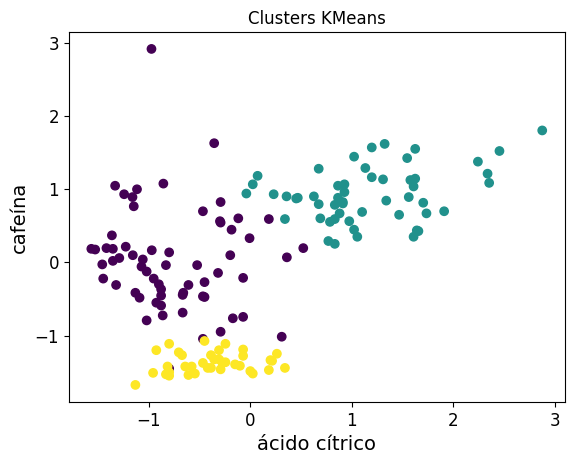

In [111]:
plt.scatter(features_scaled[:,2], features_scaled[:,0], c=labels_final, cmap='viridis')
plt.xlabel("ácido cítrico")
plt.ylabel("cafeína")
plt.title("Clusters KMeans")
plt.show();

### 7. Discusión de resultados:

- Para la relación entre cafeína y azúcares:
        - Tenemos un cluster con valores de cafeína inferiores a -1 y niveles de azúcar entre -1 y 1.5 aprox.
        - un segundo cluster con niveles de cafeína entre -1 y 1, con azúcar entre -2 y 0, con outliers.
        - un tercer cluster con niveles de cafeína entre 0.2 y 2, y azúcar entre 0 y 2 con outliers.

- Para la relación entre taurina y ácido cítrico: 
        - Hay un cluster con concentraciones bajas tanto de ácido cítrico, 0.5 o inferiores, como de taurina.
        - Otro cluster con taurina entre 0 y 2,5 aprox., con muy bajos niveles de ácido cítrico, inferiores a 0.5.
        - Un tercer cluster con niveles altos de ácido cítrico con taurina en rangos entre -0.5 y 1.5 con outliers.

- Para la relación entre cafeína y ácido cítrico:
        - La mayor concentración está en el cluster con niveles de ácido cítrico por debajo de 0, y cafeína entre -1 y 1, con outliers.
        - Un pequeño cluster con valores de ácido cítrico entre 0.5 y -1.2 aprox., junto con niveles de cafeína inferiores a -1.
        - Un tercer cluster con presencia de ácido cítrico entre 0 y 3 con valores de cafeína entre 0 y 1.5.

**Conclusiones:**
- Al negocio podemos recomendar las fórmulas con cafeína y azúcares, con ácidos cítricos y poca taurina, o con cafeína y ácido cítrico entre los valores indicados anteriormente, al ser las mezclas más comunes según los datos. 
- Son menos comunes o más arriesgadas las mezclas con taurina sin ácido cítrico o sin cafeína y con azúcares. 

### Parte II. Nuevos experimentos

Los químicos están muy esperanzados con los modelos que les habéis mostrado y os pasan una lista de nuevos experimentos para que los clasifiquéis. Emplea uno de los modelos construidos, el que te resulte más sencillo, para segmentar los nuevos experimentos que puedes encontrar en "./data/new_experiments.csv"

In [112]:
# cargo el modelo nuevo:
df_experimentos = pd.read_csv("./data/new_experiments.csv", sep="|")
df_experimentos.head()

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.481555,0.305159,1.366128,2.239039,0.731870
1,0.616869,0.890014,0.583034,0.312420,-0.665332
2,-1.680724,0.341713,-0.340615,-0.213021,-0.976782
3,-0.284874,-1.412851,-0.782361,-1.193845,-0.717240
4,-0.927212,0.634140,-1.565455,-0.085641,-0.522583


In [113]:
# selecciono las mismas features que en mi modelo entrenado:

features_experimentos = ["Cafeína", "Azúcares", "Ácido Cítrico", "Taurina"]
features_exp = df_experimentos[features_experimentos]

In [114]:
# escalo las features con los datos ya entrenados:

features_experimentos_scaled = scaler.transform(features_exp)
# scaler es el StandardScaler() ya entrenado con los datos originales
# transform() aplica la misma transformación que se calculó con los datos originales

In [115]:
# asignamos los clusters con nuestro kmeans entrenado: kmeans_final

labels_experimentos = kmeans_final.predict(features_experimentos_scaled)


In [116]:
# y agregamos la clasificación de clusters al df, y ya quedan segmentados entre clusters:

df_experimentos['cluster'] = labels_experimentos
df_experimentos.head()

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina,cluster
0,1.481555,0.305159,1.366128,2.239039,0.731870,1
1,0.616869,0.890014,0.583034,0.312420,-0.665332,1
2,-1.680724,0.341713,-0.340615,-0.213021,-0.976782,0
3,-0.284874,-1.412851,-0.782361,-1.193845,-0.717240,0
4,-0.927212,0.634140,-1.565455,-0.085641,-0.522583,0


### Parte III. EXTRA (Voluntario): 6 meses después...

La unidad de experimentación recibió un presupuesto adicional gracias a los modelos que les proporcionastes e hizo pruebas con cliente y obtuvo resultados como para clasificar cada bebida en terminos de "energización" en tres niveles (1, media; 2, media-alta, 3, alta). El resultado de los mismos está en el fichero adecuado en el directorio data y alineado con los experimentos iniciales y al final con los nuevos experimentos de la parte anterior.

Evalua la segmentación de los modelos creados en la primera parte.